In [3]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import nibabel as nib
from PIL import Image

import torch
import torch.nn as nn
from torchvision import models, transforms
from tqdm import tqdm

BASE_DIR = Path(r"C:\Users\ahmed\OneDrive\Desktop\class_seg")
PRE_DIR = BASE_DIR / "data" / "preprocessed"
TRAIN_DIR = PRE_DIR / "train"
TEST_DIR = PRE_DIR / "test"

print(TRAIN_DIR)
print(TEST_DIR)

# Load clinical xlsx for later join (not used in this step)
CLINICAL_XLSX = BASE_DIR / "Brain-Mets-Lung-MRI-Path-Segs_Clinical_Data.xlsx"
if CLINICAL_XLSX.exists():
    clinical_df = pd.read_excel(CLINICAL_XLSX, sheet_name="Clinical_Data")
    print(f"Clinical rows: {len(clinical_df)}")
else:
    clinical_df = None
    print("Clinical XLSX not found; will only export imaging features now.")


C:\Users\ahmed\OneDrive\Desktop\class_seg\data\preprocessed\train
C:\Users\ahmed\OneDrive\Desktop\class_seg\data\preprocessed\test
Clinical rows: 111


  Do not skip the ResNet preprocessing (Resize, ToTensor, Normalize) — the network expects it.
    
  - ResNet input preprocessing (the preprocess transforms)
  - ResNet50 was trained on ImageNet, which expects:
  - Images of size 224×224
  - 3 channels (RGB)
  - Pixel values normalized with ImageNet mean/std
  - This is why weights.transforms() or the manual Resize / CenterCrop / Normalize exists.
  - You still need this for ResNet — because your slices are different from ImageNet images.

In [4]:
# Build ResNet50 feature extractor (Imagenet)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# torchvision>=0.13 uses weights API
try:
    weights = models.ResNet50_Weights.IMAGENET1K_V1
    backbone = models.resnet50(weights=weights)
    preprocess = weights.transforms()
except Exception:
    backbone = models.resnet50(pretrained=True)
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

# Remove classification head; keep up to avgpool
backbone.fc = nn.Identity() # backbone.fc = the final fully connected layer (maps 2048-d → 1000 classes).
# We replace it with Identity → removes classifier.
backbone = backbone.to(device).eval()

@torch.no_grad()
def extract_image_embedding(pil_img: Image.Image) -> np.ndarray:
    x = preprocess(pil_img).unsqueeze(0).to(device)
    feat = backbone(x)  # [1, 2048]
    return feat.squeeze(0).cpu().numpy()

# Convert a single 2D slice (grayscale) to 3-channel PIL

def slice_to_rgb_pil(slice2d: np.ndarray) -> Image.Image:
    s = slice2d.astype(np.float32)
    if np.nanstd(s) > 0:
        s = (s - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s) + 1e-6)
    else:
        s = np.zeros_like(s, dtype=np.float32)
    s = (s * 255.0).clip(0, 255).astype(np.uint8)
    rgb = np.stack([s, s, s], axis=-1)
    return Image.fromarray(rgb)


Device: cuda


In [5]:
# Helper: read flair_pre.nii.gz and pick representative slices

def load_flair_slices(patient_dir: Path, max_slices: int = 15) -> list:
    flair_path = patient_dir / "flair_pre.nii.gz"
    if not flair_path.exists():
        return []
    img = nib.load(str(flair_path))
    vol = img.get_fdata()  # shape (H, W, D) or (X,Y,Z)
    if vol.ndim == 4:
        vol = vol[..., 0]
    # Select central slices evenly across depth
    D = vol.shape[-1]
    if D <= 0:
        return []
    num = min(max_slices, D)
    indices = np.linspace(D*0.25, D*0.75, num=num, endpoint=True).astype(int)
    slices = [vol[..., i] for i in indices]
    return slices

@torch.no_grad()
def extract_patient_feature(patient_dir: Path) -> np.ndarray:
    slices = load_flair_slices(patient_dir)
    if len(slices) == 0:
        return None
    feats = []
    for s in slices:
        pil_img = slice_to_rgb_pil(s)
        feats.append(extract_image_embedding(pil_img))  # (2048,)
    feats = np.stack(feats, axis=0)  # (N, 2048)
    mean_feat = feats.mean(axis=0)
    return mean_feat  # (2048,)


In [6]:
# Iterate train/test directories, compute features, and save

def collect_patient_dirs(split_dir: Path) -> list:
    # patient directory names are IDs
    return sorted([p for p in split_dir.iterdir() if p.is_dir()])


def build_features(split_dir: Path) -> pd.DataFrame:
    rows = []
    patient_dirs = collect_patient_dirs(split_dir)
    for pdir in tqdm(patient_dirs, desc=f"Extracting from {split_dir.name}"):
        pid = pdir.name
        feat = extract_patient_feature(pdir)
        if feat is None:
            continue
        row = {"patient_id": pid}
        for i, v in enumerate(feat.tolist()):
            row[f"f_{i}"] = v
        rows.append(row)
    return pd.DataFrame(rows)

train_df = build_features(TRAIN_DIR) if TRAIN_DIR.exists() else pd.DataFrame()
test_df = build_features(TEST_DIR) if TEST_DIR.exists() else pd.DataFrame()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Save to disk
OUT_DIR = BASE_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
train_csv = OUT_DIR / "flair_resnet50_train_features.csv"
test_csv = OUT_DIR / "flair_resnet50_test_features.csv"
train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)
print("Saved:", train_csv)
print("Saved:", test_csv)

# Preview vectors for first few patients
train_df.head(3)


Extracting from test: 100%|██████████| 19/19 [00:03<00:00,  6.29it/s]


Train shape: (77, 2049)
Test shape: (19, 2049)
Saved: C:\Users\ahmed\OneDrive\Desktop\class_seg\outputs\flair_resnet50_train_features.csv
Saved: C:\Users\ahmed\OneDrive\Desktop\class_seg\outputs\flair_resnet50_test_features.csv


,patient_id,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_2038,f_2039,f_2040,f_2041,f_2042,f_2043,f_2044,f_2045,f_2046,f_2047
0,YG_0AXGKD8AFJGS,0.196266,0.112766,0.116657,0.360902,0.101798,0.451756,0.295030,0.364334,0.406490,...,0.319269,0.248399,0.385638,0.127838,0.494846,0.081731,0.985674,0.540112,0.259230,0.294178
1,YG_0IBUXTBINCD9,0.277799,0.519898,0.420219,0.277010,0.277902,0.473221,0.356098,0.159044,0.669901,...,0.783140,0.360633,0.573095,0.382738,0.302881,0.057350,0.857157,0.672699,0.108251,0.484855
2,YG_1BZ1NP805Q9J,0.268915,0.211168,0.169979,0.144928,0.232474,0.231683,0.179334,0.040266,0.893687,...,0.426182,0.113608,0.507516,0.593785,0.449497,0.134028,0.569753,0.991000,0.087334,0.393559


# Preprocessing clinical data 
- making the columns numeric
- apply scaling/normalization across all numeric clinical variables at once.

In [57]:
import pandas as pd
from pathlib import Path

CLINICAL_XLSX = Path("Brain-Mets-Lung-MRI-Path-Segs_Clinical_Data.xlsx")  # change if needed

# --- load all sheets quickly to confirm names & sizes
sheets = pd.read_excel(CLINICAL_XLSX, sheet_name=None)
print("Sheets and shapes:", {name: df.shape for name, df in sheets.items()})

# --- load the clinical sheet we want
clinical_df = pd.read_excel(CLINICAL_XLSX, sheet_name="Clinical_Data")

# --- tidy column names for easier handling (non-destructive)
clinical_df.columns = (
    clinical_df.columns
    .str.strip()
    .str.replace('\n', ' ', regex=False)
    .str.replace(r'[^\w\s]', '', regex=True)   # remove punctuation
    .str.replace(' ', '_', regex=False)
    .str.lower()
)

# --- quick views
print("\nShape:", clinical_df.shape)
print("\nFirst 8 rows:\n", clinical_df.head(8))
print("\nDataFrame info:")
clinical_df.info()

# --- missing values (descending)
print("\nMissing values by column:")
print(clinical_df.isna().sum().sort_values(ascending=False))

# --- duplicates check (patient id & accession)
for key in ["patient_id", "accession"]:
    if key in clinical_df.columns:
        print(f"\nDuplicate rows by {key}:", clinical_df.duplicated(subset=[key]).sum())
        print(clinical_df[clinical_df.duplicated(subset=[key], keep=False)].sort_values(by=key).head(10))

# --- unique value summary for each column (useful to decide encoding)
print("\nColumn summary (nunique and sample values):")
for col in clinical_df.columns:
    nun = clinical_df[col].nunique(dropna=False)
    print(f" - {col}: nunique={nun}", end="")
    if nun <= 12:
        print("  values:", clinical_df[col].dropna().unique().tolist())
    else:
        sample = clinical_df[col].dropna().unique()[:10].tolist()
        print("  sample:", sample)

# Save a copy (optional) so you can inspect in Excel if desired
clinical_df.to_csv("clinical_data_clean_preview.csv", index=False)
print("\nSaved a preview CSV: clinical_data_clean_preview.csv")


Sheets and shapes: {'Data Dictionary-Clinical Data': (18, 2), 'Clinical_Data': (111, 18), 'Radiomics': (111, 216), 'Image_Data': (111, 19)}

Shape: (111, 18)

First 8 rows:
          accession       patient_id  age_at_bm_dx     sex packyear_smoking_hx  \
0  YG_XKGYFGZHUMTO  YG_0427RC24FT6W            72  Female                  76   
1  YG_HAEAKFOSOSWC  YG_0AXGKD8AFJGS            65    Male                  23   
2  YG_985XO5NHL516  YG_0IBUXTBINCD9            56  Female                  34   
3  YG_WNJIJZXQW7BT  YG_0LCI9NV44UK0            70  Female                  40   
4  YG_3ULZIC6OE5NB  YG_1BZ1NP805Q9J            63  Female                  15   
5  YG_6U4LW891P2JA  YG_1PHFOPJWEXFN            50  Female                   9   
6  YG_U8D90FYR7XQ6  YG_1PHFOPJWEXFN            50  Female                   9   
7  YG_QDPH4L1OB5Q3  YG_29KZUMN7VC2P            61  Female                  10   

         nih_racial_category  kps_at_bm_dx  age_at_resection  \
0                      White    

In [58]:
clinical_df["packyear_smoking_hx"] = (
    clinical_df["packyear_smoking_hx"]
    .replace("Never", 0)      # replace 'never' with 0
    .astype(float)            # convert everything to float
)

print(clinical_df["packyear_smoking_hx"].head(10))

#clinical_df["nih_racial_category"].unique()
clinical_df = pd.get_dummies(clinical_df, columns=['nih_racial_category'])
clinical_df['sex'] = clinical_df['sex'].map({'Female': 0, 'Male': 1})


0    76.0
1    23.0
2    34.0
3    40.0
4    15.0
5     9.0
6     9.0
7    10.0
8     5.0
9    15.0
Name: packyear_smoking_hx, dtype: float64


C:\Users\ahmed\AppData\Local\Temp\ipykernel_2956\1639815786.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("Never", 0)      # replace 'never' with 0


In [59]:
# Function to map lesion locations to broader categories
def map_lesion_location(loc):
    loc = loc.lower()
    if 'frontal' in loc:
        return 'frontal'
    elif 'temporal' in loc:
        return 'temporal'
    elif 'parietal' in loc:
        return 'parietal'
    elif 'occipital' in loc:
        return 'occipital'
    elif 'cerebellum' in loc:
        return 'cerebellum'
    else:
        return 'other'

# Apply mapping
clinical_df['lesion_location_grouped'] = clinical_df['location_of_lesion'].apply(map_lesion_location)

# One-hot encode the new grouped column
location_dummies = pd.get_dummies(clinical_df['lesion_location_grouped'], prefix='loc')
clinical_df = pd.concat([clinical_df, location_dummies], axis=1)

# Optional: drop original columns if you only want the grouped features
clinical_df = clinical_df.drop(['location_of_lesion', 'lesion_location_grouped'], axis=1)

In [60]:
def map_histologic_subtype(loc):
    loc = loc.lower()
    if 'sclc' in loc:
        return 'SCLC'
    elif 'nsclc' in loc:
        return 'NSCLC'
    elif 'adenocarcinoma' in loc:
        return 'Adenocarcinoma'
    elif 'luad' in loc:
        return 'LUAD'
    else:
        return 'other'

# Apply mapping
clinical_df['histologic_subtype_grouped'] = clinical_df['histologic_subtype'].apply(map_histologic_subtype)

# One-hot encode the new grouped column
hist_dummies = pd.get_dummies(clinical_df['histologic_subtype_grouped'], prefix='hist')
clinical_df = pd.concat([clinical_df, hist_dummies], axis=1)

# Optional: drop original columns if you only want the grouped features
clinical_df = clinical_df.drop(['histologic_subtype', 'histologic_subtype_grouped'], axis=1)

In [61]:
gpa_dummies = pd.get_dummies(clinical_df['gpa_histology_class'], prefix='gpa')
clinical_df = pd.concat([clinical_df, gpa_dummies], axis=1)
clinical_df = clinical_df.drop(['gpa_histology_class'], axis=1)

In [64]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns (ints and floats that are not one-hot encoded)
numeric_cols = ['age_at_bm_dx', 'packyear_smoking_hx', 'kps_at_bm_dx',
                'age_at_resection', 'size_of_dominant_lesion',
                'number_of_bm_lesions_at_dx', 'sperduto_gpa']

scaler = StandardScaler()
clinical_df[numeric_cols] = scaler.fit_transform(clinical_df[numeric_cols])

#removing duplicates
clinical_df = clinical_df.drop_duplicates(subset='patient_id', keep='first').reset_index(drop=True)

In [70]:
# Load test features CSV
test_feats_df = pd.read_csv("outputs/flair_resnet50_test_features.csv")

# Make sure patient_id is the same dtype as in clinical_df
test_feats_df['patient_id'] = test_feats_df['patient_id'].astype(str)

# Merge with clinical data (dropping duplicates first)
clinical_test_df = clinical_df.merge(test_feats_df, on='patient_id', how='inner')

print(clinical_test_df.shape)
clinical_test_df.head()


(19, 2079)


,accession,patient_id,age_at_bm_dx,sex,packyear_smoking_hx,kps_at_bm_dx,age_at_resection,size_of_dominant_lesion,number_of_bm_lesions_at_dx,presence_of_extracranial_mets_at_dx_1__yes_0__no,...,f_2038,f_2039,f_2040,f_2041,f_2042,f_2043,f_2044,f_2045,f_2046,f_2047
0,YG_XKGYFGZHUMTO,YG_0427RC24FT6W,0.735073,0,1.729714,-0.477012,0.782448,0.953595,-0.542323,1,...,0.509220,0.235318,0.363258,0.338855,0.733123,0.053381,0.757909,1.003394,0.338515,0.344577
1,YG_WNJIJZXQW7BT,YG_0LCI9NV44UK0,0.511530,0,0.255953,0.248308,0.447113,-1.435973,0.185143,1,...,0.331330,0.075582,0.198781,0.330247,0.198775,0.085656,0.554377,0.743628,0.156977,0.334258
2,YG_6U4LW891P2JA,YG_1PHFOPJWEXFN,-1.723896,0,-1.013118,0.973627,-1.788452,-0.550948,-0.542323,0,...,0.575582,0.325891,0.119363,0.159501,0.193962,0.055522,0.264703,0.600647,0.335460,0.463851
3,YG_748ADE23A96L,YG_4C0NA9IRB1QB,0.399759,1,1.688776,1.698947,0.335335,-0.373943,-0.542323,0,...,0.607581,0.117794,0.094879,0.122240,0.416546,0.076175,0.356535,0.350642,0.417276,0.366910
4,YG_34W2PP4X6FL6,YG_5E1M7C728HGS,-1.165040,1,-0.317176,-0.477012,-1.229560,0.776590,0.003277,1,...,0.774860,0.050911,0.372029,0.447255,0.276864,0.190657,0.859636,0.816982,0.318935,0.378974


In [72]:
# Load test features CSV
train_feats_df = pd.read_csv("outputs/flair_resnet50_train_features.csv")

# Make sure patient_id is the same dtype as in clinical_df
train_feats_df['patient_id'] = train_feats_df['patient_id'].astype(str)

# Merge with clinical data (dropping duplicates first)
clinical_train_df = clinical_df.merge(train_feats_df, on='patient_id', how='inner')

print(clinical_train_df.shape)
clinical_train_df.head()


(77, 2079)


,accession,patient_id,age_at_bm_dx,sex,packyear_smoking_hx,kps_at_bm_dx,age_at_resection,size_of_dominant_lesion,number_of_bm_lesions_at_dx,presence_of_extracranial_mets_at_dx_1__yes_0__no,...,f_2038,f_2039,f_2040,f_2041,f_2042,f_2043,f_2044,f_2045,f_2046,f_2047
0,YG_HAEAKFOSOSWC,YG_0AXGKD8AFJGS,-0.047327,1,-0.439989,1.698947,-0.111778,-0.108436,-0.360456,1,...,0.319269,0.248399,0.385638,0.127838,0.494846,0.081731,0.985674,0.540112,0.259230,0.294178
1,YG_985XO5NHL516,YG_0IBUXTBINCD9,-1.053268,0,0.010327,1.698947,-1.117782,0.599585,0.185143,1,...,0.783140,0.360633,0.573095,0.382738,0.302881,0.057350,0.857157,0.672699,0.108251,0.484855
2,YG_3ULZIC6OE5NB,YG_1BZ1NP805Q9J,-0.270869,0,-0.767492,0.973627,-0.335335,-1.878486,-0.178590,1,...,0.426182,0.113608,0.507516,0.593785,0.449497,0.134028,0.569753,0.991000,0.087334,0.393559
3,YG_QDPH4L1OB5Q3,YG_29KZUMN7VC2P,-0.494412,0,-0.972181,-1.202332,-0.558891,-1.435973,-0.542323,1,...,0.258218,0.168389,0.443450,0.452913,0.631265,0.099794,0.530907,0.419276,0.038236,0.403420
4,YG_MGO4964VSKLW,YG_2GBL4CHD8WHX,-0.606183,0,-1.176870,-1.202332,-0.670669,-0.196938,0.730743,1,...,0.188637,0.049367,0.180406,0.400527,0.454669,0.058320,0.402658,0.559290,0.339559,0.610665


In [68]:
# Show the first 10 rows to see the new dummy columns
clinical_df.head(10)#.filter(like='nih_racial_category')

,accession,patient_id,age_at_bm_dx,sex,packyear_smoking_hx,kps_at_bm_dx,age_at_resection,size_of_dominant_lesion,number_of_bm_lesions_at_dx,presence_of_extracranial_mets_at_dx_1__yes_0__no,...,loc_other,loc_parietal,loc_temporal,hist_Adenocarcinoma,hist_LUAD,hist_SCLC,hist_other,gpa_NSCLC Adenocarcinoma,gpa_NSCLC Non-adenocarcinoma,gpa_SCLC
0,YG_XKGYFGZHUMTO,YG_0427RC24FT6W,0.735073,0,1.729714,-0.477012,0.782448,0.953595,-0.542323,1,...,False,False,False,False,False,True,False,False,False,True
1,YG_HAEAKFOSOSWC,YG_0AXGKD8AFJGS,-0.047327,1,-0.439989,1.698947,-0.111778,-0.108436,-0.360456,1,...,False,False,False,True,False,False,False,True,False,False
2,YG_985XO5NHL516,YG_0IBUXTBINCD9,-1.053268,0,0.010327,1.698947,-1.117782,0.599585,0.185143,1,...,False,False,False,False,False,False,True,False,True,False
3,YG_WNJIJZXQW7BT,YG_0LCI9NV44UK0,0.511530,0,0.255953,0.248308,0.447113,-1.435973,0.185143,1,...,False,True,False,False,False,True,False,False,True,False
4,YG_3ULZIC6OE5NB,YG_1BZ1NP805Q9J,-0.270869,0,-0.767492,0.973627,-0.335335,-1.878486,-0.178590,1,...,False,False,False,True,False,False,False,True,False,False
5,YG_6U4LW891P2JA,YG_1PHFOPJWEXFN,-1.723896,0,-1.013118,0.973627,-1.788452,-0.550948,-0.542323,0,...,False,False,False,True,False,False,False,True,False,False
6,YG_QDPH4L1OB5Q3,YG_29KZUMN7VC2P,-0.494412,0,-0.972181,-1.202332,-0.558891,-1.435973,-0.542323,1,...,False,False,False,True,False,False,False,True,False,False
7,YG_MGO4964VSKLW,YG_2GBL4CHD8WHX,-0.606183,0,-1.176870,-1.202332,-0.670669,-0.196938,0.730743,1,...,False,False,False,True,False,False,False,True,False,False
8,YG_PT6LAWSXHST3,YG_2XR67085OZD3,0.735073,1,-0.767492,-1.202332,0.670669,-0.373943,1.821942,1,...,False,False,False,True,False,False,False,True,False,False
9,YG_XY6SP25JK2UJ,YG_319S0V0DN4BI,0.623301,1,-1.340621,0.973627,0.558891,-0.904958,-0.542323,0,...,False,False,False,True,False,False,False,True,False,False


# Training & eveluating XG_Boost

In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Suppose clinical_train_df is your full train dataset with target included
# Step 1: define X and y
target_col = 'presence_of_extracranial_mets_at_dx_1__yes_0__no'
X = clinical_train_df.drop(columns=[target_col, 'patient_id', 'accession'])  # remove target and identifiers
y = clinical_train_df[target_col]

# Step 2: train/test split (here we split a validation set from train)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: train XGBoost
neg, pos = (y_train==0).sum(), (y_train==1).sum()
scale_pos_weight = neg / pos

model = XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss')
model.fit(X_train, y_train)

# Step 4: evaluate
y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))


c:\Users\ahmed\OneDrive\Desktop\class_seg\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:44:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.625
              precision    recall  f1-score   support

           0       0.33      0.20      0.25         5
           1       0.69      0.82      0.75        11

    accuracy                           0.62        16
   macro avg       0.51      0.51      0.50        16
weighted avg       0.58      0.62      0.59        16



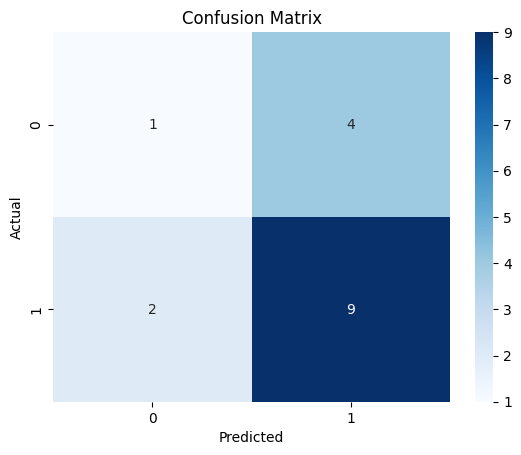

In [90]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


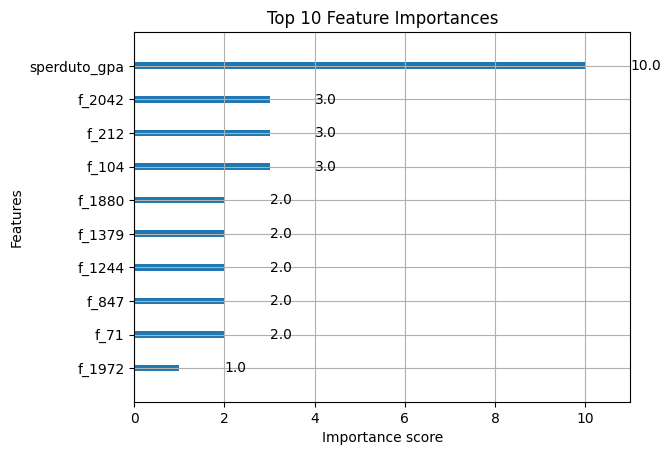

In [91]:
from xgboost import plot_importance

plot_importance(model, max_num_features=10)
plt.title("Top 10 Feature Importances")
plt.show()


# Training and evaluating Random Forest

In [88]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Initialize the model
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Fit on training data
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_val)

print("RF with class_weight='balanced'")
print(classification_report(y_val, y_pred))
print(confusion_matrix(y_val, y_pred))

RF with class_weight='balanced'
              precision    recall  f1-score   support

           0       0.50      0.20      0.29         5
           1       0.71      0.91      0.80        11

    accuracy                           0.69        16
   macro avg       0.61      0.55      0.54        16
weighted avg       0.65      0.69      0.64        16

[[ 1  4]
 [ 1 10]]


In [86]:
# --- Option 2: Using SMOTE ---
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_res, y_train_res)
y_pred_smote = rf_smote.predict(X_val)

print("RF with SMOTE")
print(classification_report(y_val, y_pred_smote))
print(confusion_matrix(y_val, y_pred_smote))

RF with SMOTE
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.69      1.00      0.81        11

    accuracy                           0.69        16
   macro avg       0.34      0.50      0.41        16
weighted avg       0.47      0.69      0.56        16

[[ 0  5]
 [ 0 11]]


c:\Users\ahmed\OneDrive\Desktop\class_seg\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ahmed\OneDrive\Desktop\class_seg\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ahmed\OneDrive\Desktop\class_seg\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

RF Accuracy: 0.69
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.69      1.00      0.81        11

    accuracy                           0.69        16
   macro avg       0.34      0.50      0.41        16
weighted avg       0.47      0.69      0.56        16



c:\Users\ahmed\OneDrive\Desktop\class_seg\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ahmed\OneDrive\Desktop\class_seg\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ahmed\OneDrive\Desktop\class_seg\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

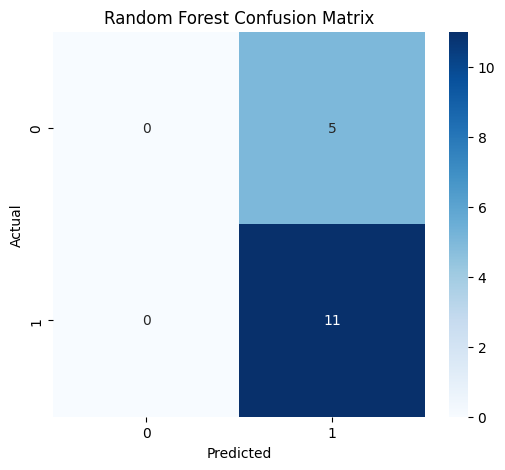

In [84]:
# Accuracy
acc_rf = accuracy_score(y_val, y_pred_rf)
print(f"RF Accuracy: {acc_rf:.2f}")

# Classification report
print(classification_report(y_val, y_pred_rf))

# Confusion matrix
cm_rf = confusion_matrix(y_val, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()
